In [1]:
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv("C:\\Users\\yalam\\OneDrive\\Desktop\\new-york-city-taxi-fare-prediction\\train.csv")
test_data = pd.read_csv("C:\\Users\\yalam\\OneDrive\\Desktop\\new-york-city-taxi-fare-prediction\\test.csv")

In [3]:
train_data_sample = train_data.sample(n=10000, random_state=42)
print(train_data_sample.head())

                                    key  fare_amount          pickup_datetime  \
10478479  2010-01-16 20:06:00.000000168          3.3  2010-01-16 20:06:00 UTC   
2240033    2010-09-22 23:21:00.00000065          6.5  2010-09-22 23:21:00 UTC   
24966385    2013-10-17 18:40:14.0000001          5.0  2013-10-17 18:40:14 UTC   
38721384    2015-06-09 19:39:42.0000009         40.5  2015-06-09 19:39:42 UTC   
41464765    2012-05-01 07:16:59.0000001          7.7  2012-05-01 07:16:59 UTC   

          pickup_longitude  pickup_latitude  dropoff_longitude  \
10478479        -73.953323        40.778532         -73.953375   
2240033         -73.985542        40.738333         -74.003350   
24966385        -73.999945        40.718097         -73.999239   
38721384        -73.974533        40.756237         -73.923149   
41464765        -73.952835        40.786351         -73.974022   

          dropoff_latitude  passenger_count  
10478479         40.772505                1  
2240033          40.7389

In [4]:
print("Data Info:")
print(train_data.info())

print("\nData Description:")
print(train_data.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55423856 entries, 0 to 55423855
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   key                object 
 1   fare_amount        float64
 2   pickup_datetime    object 
 3   pickup_longitude   float64
 4   pickup_latitude    float64
 5   dropoff_longitude  float64
 6   dropoff_latitude   float64
 7   passenger_count    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.3+ GB
None

Data Description:
        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  5.542386e+07      5.542386e+07     5.542386e+07       5.542348e+07   
mean   1.134505e+01     -7.250968e+01     3.991979e+01      -7.251121e+01   
std    2.071083e+01      1.284888e+01     9.642353e+00       1.278220e+01   
min   -3.000000e+02     -3.442060e+03    -3.492264e+03      -3.442025e+03   
25%    6.000000e+00     -7.399207e+01     4.073493e+01      -7.399140e+01   
50%    

In [5]:
missing_data = train_data.isnull().sum()
print("\nMissing Data Summary:")
print(missing_data) 


Missing Data Summary:
key                    0
fare_amount            0
pickup_datetime        0
pickup_longitude       0
pickup_latitude        0
dropoff_longitude    376
dropoff_latitude     376
passenger_count        0
dtype: int64


In [6]:
train_data = train_data.dropna(subset=['dropoff_latitude', 'dropoff_longitude'])

print("Data shape after dropping rows with missing dropoff coordinates:", train_data.shape)

Data shape after dropping rows with missing dropoff coordinates: (55423480, 8)


In [7]:
train_data['pickup_datetime'] = pd.to_datetime(train_data['pickup_datetime'])

train_data['pickup_month'] = train_data['pickup_datetime'].dt.month
train_data['pickup_day'] = train_data['pickup_datetime'].dt.day
train_data['pickup_hour'] = train_data['pickup_datetime'].dt.hour

print("Data with datetime features:")
print(train_data[['pickup_datetime', 'pickup_month', 'pickup_day', 'pickup_hour']].head())

Data with datetime features:
            pickup_datetime  pickup_month  pickup_day  pickup_hour
0 2009-06-15 17:26:21+00:00             6          15           17
1 2010-01-05 16:52:16+00:00             1           5           16
2 2011-08-18 00:35:00+00:00             8          18            0
3 2012-04-21 04:30:42+00:00             4          21            4
4 2010-03-09 07:51:00+00:00             3           9            7


In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371 

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    distance = R * c
    return distance

train_data['haversine_distance'] = haversine_distance(
    train_data['pickup_latitude'],
    train_data['pickup_longitude'],
    train_data['dropoff_latitude'],
    train_data['dropoff_longitude']
)

print("Data with haversine distance feature:")
print(train_data[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'haversine_distance']].head())

Data with haversine distance feature:
   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.721319        -73.844311         40.712278         -73.841610   
1        40.711303        -74.016048         40.782004         -73.979268   
2        40.761270        -73.982738         40.750562         -73.991242   
3        40.733143        -73.987130         40.758092         -73.991567   
4        40.768008        -73.968095         40.783762         -73.956655   

   haversine_distance  
0            1.030764  
1            8.450134  
2            1.389525  
3            2.799270  
4            1.999157  


In [9]:
train_data['delta_latitude'] = train_data['pickup_latitude'] - train_data['dropoff_latitude']
train_data['delta_longitude'] = train_data['pickup_longitude'] - train_data['dropoff_longitude']

train_data['manhattan_distance'] = (train_data['delta_latitude'].abs() + train_data['delta_longitude'].abs())

print("Data with delta and Manhattan distance features:")
print(train_data[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 
                  'delta_latitude', 'delta_longitude', 'manhattan_distance']].head())

Data with delta and Manhattan distance features:
   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.721319        -73.844311         40.712278         -73.841610   
1        40.711303        -74.016048         40.782004         -73.979268   
2        40.761270        -73.982738         40.750562         -73.991242   
3        40.733143        -73.987130         40.758092         -73.991567   
4        40.768008        -73.968095         40.783762         -73.956655   

   delta_latitude  delta_longitude  manhattan_distance  
0        0.009041        -0.002701            0.011742  
1       -0.070701        -0.036780            0.107481  
2        0.010708         0.008504            0.019212  
3       -0.024949         0.004437            0.029386  
4       -0.015754        -0.011440            0.027194  


In [10]:
# Clean fare_amount
train_data = train_data[(train_data['fare_amount'] > 0) & (train_data['fare_amount'] < 500)]

# Clean passenger_count
train_data = train_data[(train_data['passenger_count'] > 0) & (train_data['passenger_count'] <= 6)]

# Clean coordinates
train_data = train_data[
    (train_data['pickup_latitude'] >= 40) & (train_data['pickup_latitude'] <= 42) &
    (train_data['pickup_longitude'] >= -75) & (train_data['pickup_longitude'] <= -72) &
    (train_data['dropoff_latitude'] >= 40) & (train_data['dropoff_latitude'] <= 42) &
    (train_data['dropoff_longitude'] >= -75) & (train_data['dropoff_longitude'] <= -72)
]

# Final shape after cleaning
print(f"Shape after cleaning: {train_data.shape}")


Shape after cleaning: (54063034, 15)


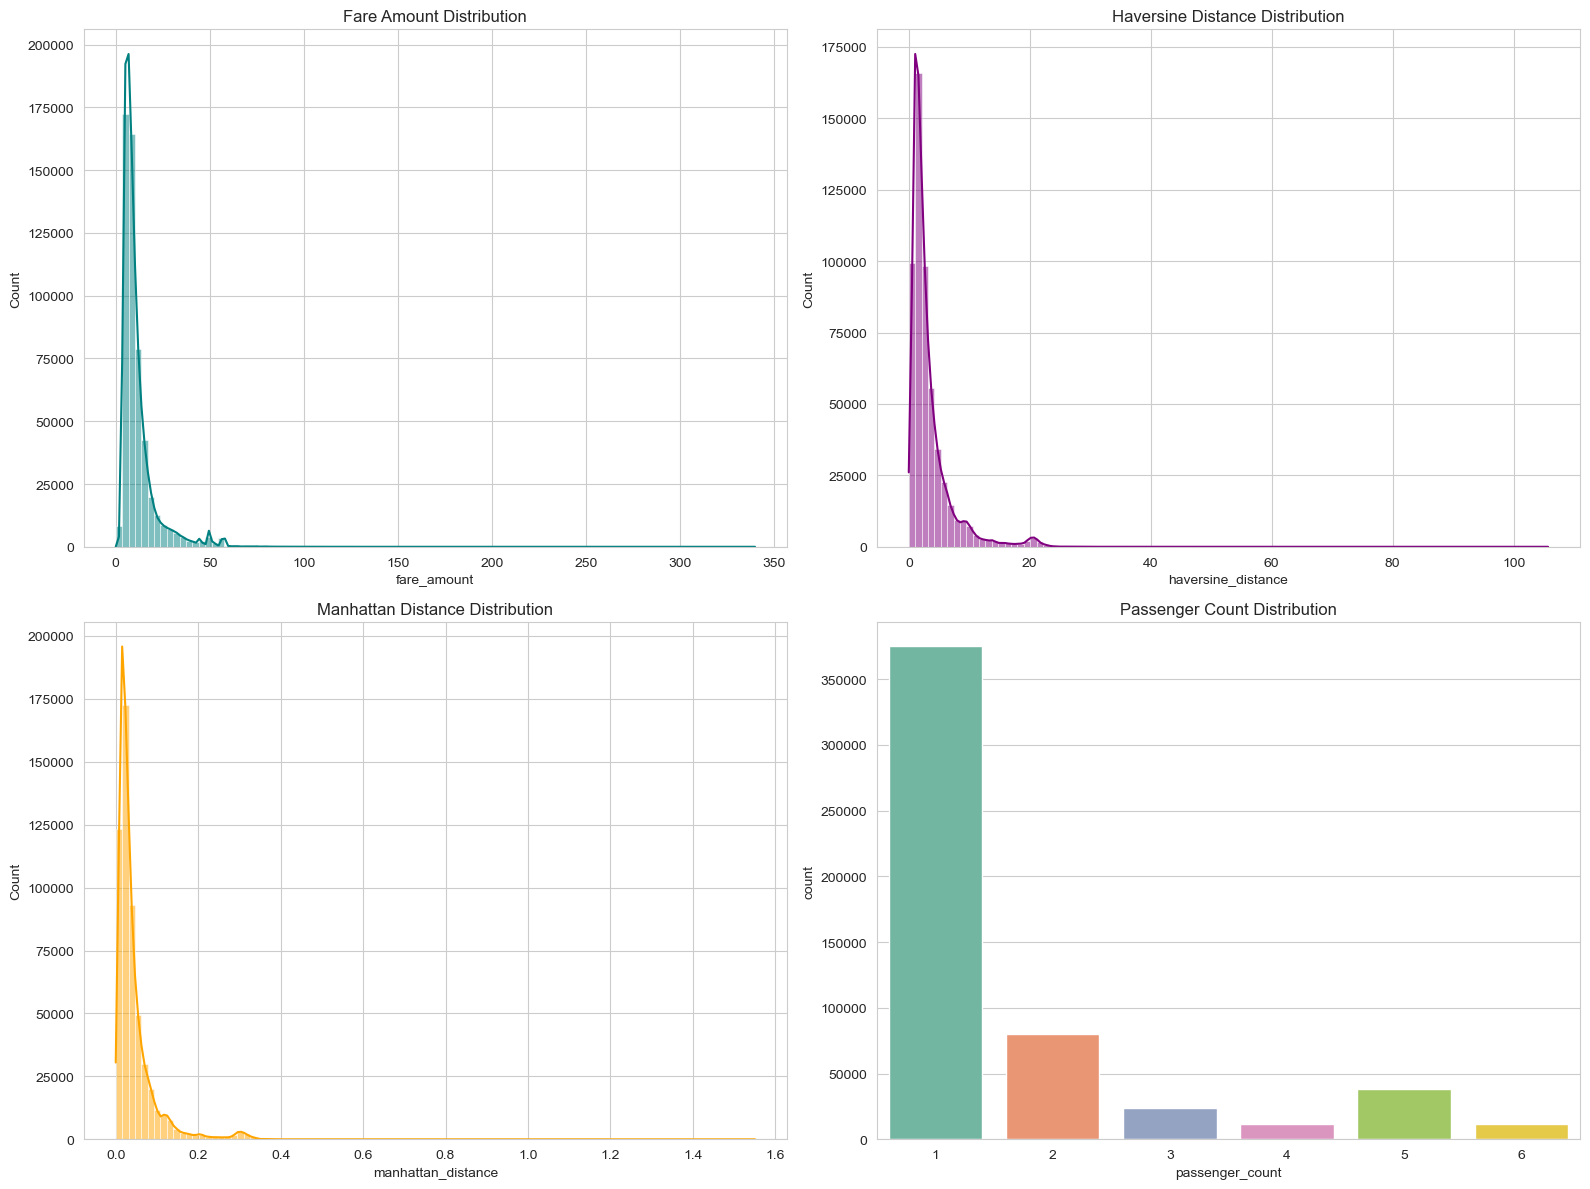

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# Sample 1% of the dataset for plotting (you can adjust this value)
train_data_sample = train_data.sample(frac=0.01, random_state=42)

# Set general plot style
sns.set_style('whitegrid')

# Plot distributions
plt.figure(figsize=(16, 12))

# Fare Amount
plt.subplot(2, 2, 1)
sns.histplot(train_data_sample['fare_amount'], bins=100, kde=True, color='teal')
plt.title('Fare Amount Distribution')

# Haversine Distance
plt.subplot(2, 2, 2)
sns.histplot(train_data_sample['haversine_distance'], bins=100, kde=True, color='purple')
plt.title('Haversine Distance Distribution')

# Manhattan Distance
plt.subplot(2, 2, 3)
sns.histplot(train_data_sample['manhattan_distance'], bins=100, kde=True, color='orange')
plt.title('Manhattan Distance Distribution')

# Passenger Count (Updated)
plt.subplot(2, 2, 4)
sns.countplot(x='passenger_count', data=train_data_sample, hue='passenger_count', palette='Set2', legend=False)
plt.title('Passenger Count Distribution')

plt.tight_layout()
plt.show()

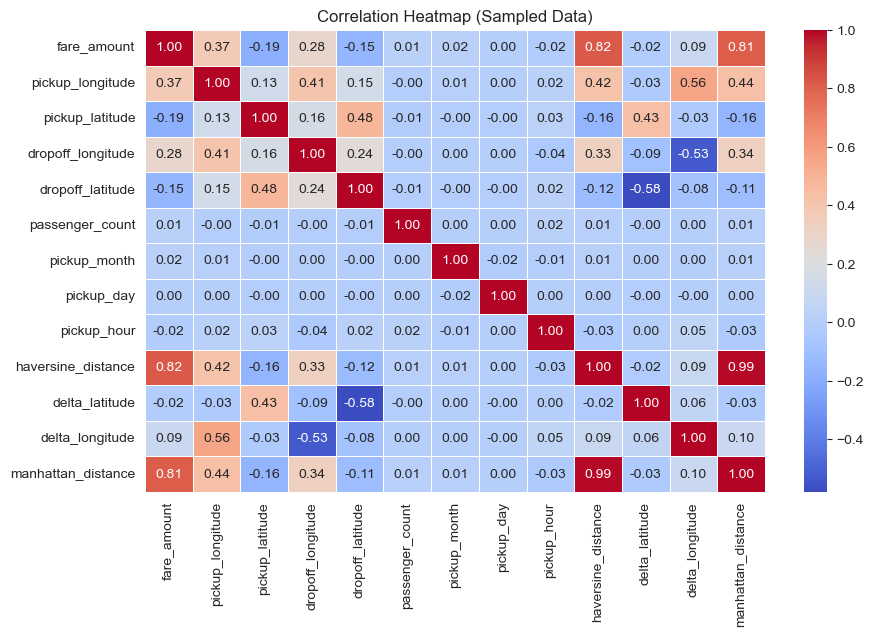

In [12]:
# Sample a subset of the data to reduce memory usage
train_data_sample = train_data.sample(frac=0.1, random_state=42)  # 10% sample

# Select only numeric columns
numeric_data_sample = train_data_sample.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr = numeric_data_sample.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Sampled Data)')
plt.show()


## Feature Engineering

In [14]:
from sklearn.preprocessing import StandardScaler
# Downsample the data to 10% of the original size
train_data_sampled = train_data.sample(frac=0.1, random_state=42)

# 1. Creating Interaction Feature
train_data_sampled['fare_per_passenger'] = train_data_sampled['fare_amount'] / train_data_sampled['passenger_count']

# 2. Apply log transformation on fare_amount (to reduce skewness)
train_data_sampled['log_fare_amount'] = np.log1p(train_data_sampled['fare_amount'])  # log1p handles log(0)

# 3. Feature Scaling using StandardScaler
scaler = StandardScaler()

# Selecting numeric columns for scaling
numeric_columns = train_data_sampled.select_dtypes(include=[np.number]).columns

# Apply scaling
train_data_sampled[numeric_columns] = scaler.fit_transform(train_data_sampled[numeric_columns])

# Verify the new features and scaled data
train_data_sampled.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_month,pickup_day,pickup_hour,haversine_distance,delta_latitude,delta_longitude,manhattan_distance,fare_per_passenger,log_fare_amount
32662962,2009-01-20 13:32:06.0000001,-0.787637,2009-01-20 13:32:06+00:00,-0.680471,-0.146043,-0.559424,-0.066750,-0.528865,-1.533759,0.493473,-0.079130,-0.728169,-0.066977,-0.122537,-0.672460,-0.603042,-1.437528
43755105,2011-12-03 10:50:39.0000002,0.162270,2011-12-03 10:50:39+00:00,-0.257505,-0.794754,-0.156690,0.729804,-0.528865,1.667747,-1.463786,-0.539535,0.546569,-1.488450,-0.096496,0.173045,0.428885,0.547451
52146280,2013-05-29 13:57:00.000000198,-0.601786,2013-05-29 13:57:00+00:00,0.109385,0.006420,-0.076871,-0.149143,-0.528865,-0.369575,1.529669,-0.079130,-0.681484,0.159323,0.171690,-0.623122,-0.401144,-0.843972
6195543,2011-09-07 20:52:35.0000004,-0.044232,2011-09-07 20:52:35+00:00,0.143287,0.434599,-0.318710,-1.875923,-0.528865,0.794609,-1.003254,0.995148,1.355308,2.332545,0.423564,0.900570,0.204553,0.263065
21944980,2011-03-12 11:04:37.0000003,-0.333334,2011-03-12 11:04:37+00:00,-0.562674,-0.654643,-0.120863,0.313710,-0.528865,-0.951667,-0.427590,-0.386067,0.100182,-0.930482,-0.412711,0.083531,-0.109512,-0.228022


In [15]:
# Check for missing values in the dataset
train_data.isnull().sum()


key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
passenger_count       0
pickup_month          0
pickup_day            0
pickup_hour           0
haversine_distance    0
delta_latitude        0
delta_longitude       0
manhattan_distance    0
dtype: int64

In [16]:
import numpy as np

# Create 'fare_per_passenger' and 'log_fare_amount' columns
train_data['fare_per_passenger'] = train_data['fare_amount'] / train_data['passenger_count']
train_data['log_fare_amount'] = np.log1p(train_data['fare_amount'])  # Using log1p to avoid log(0)

# Check the new columns
train_data[['fare_per_passenger', 'log_fare_amount']].head()


,fare_per_passenger,log_fare_amount
0,4.50,1.704748
1,16.90,2.884801
2,2.85,1.902108
3,7.70,2.163323
4,5.30,1.840550


In [17]:
from sklearn.preprocessing import StandardScaler

# Step 1: Create new interaction features
train_data['fare_per_passenger'] = train_data['fare_amount'] / train_data['passenger_count']
train_data['log_fare_amount'] = np.log1p(train_data['fare_amount'])  # avoid log(0)

# Step 2: Downsample to avoid MemoryError (10% of data)
train_data_sampled = train_data.sample(frac=0.1, random_state=42)

# Step 3: Select numeric columns only
numeric_columns = train_data_sampled.select_dtypes(include=[np.number]).columns

# Step 4: Apply StandardScaler
scaler = StandardScaler()
train_data_sampled[numeric_columns] = scaler.fit_transform(train_data_sampled[numeric_columns])

# Step 5: Preview to confirm everything worked
train_data_sampled[numeric_columns].head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_month,pickup_day,pickup_hour,haversine_distance,delta_latitude,delta_longitude,manhattan_distance,fare_per_passenger,log_fare_amount
32662962,-0.787637,-0.680471,-0.146043,-0.559424,-0.066750,-0.528865,-1.533759,0.493473,-0.079130,-0.728169,-0.066977,-0.122537,-0.672460,-0.603042,-1.437528
43755105,0.162270,-0.257505,-0.794754,-0.156690,0.729804,-0.528865,1.667747,-1.463786,-0.539535,0.546569,-1.488450,-0.096496,0.173045,0.428885,0.547451
52146280,-0.601786,0.109385,0.006420,-0.076871,-0.149143,-0.528865,-0.369575,1.529669,-0.079130,-0.681484,0.159323,0.171690,-0.623122,-0.401144,-0.843972
6195543,-0.044232,0.143287,0.434599,-0.318710,-1.875923,-0.528865,0.794609,-1.003254,0.995148,1.355308,2.332545,0.423564,0.900570,0.204553,0.263065
21944980,-0.333334,-0.562674,-0.654643,-0.120863,0.313710,-0.528865,-0.951667,-0.427590,-0.386067,0.100182,-0.930482,-0.412711,0.083531,-0.109512,-0.228022


In [35]:
# Step 5: Define X and y safely
X = train_data_sampled.select_dtypes(include=[np.number]).drop(columns=['fare_amount'])
y = train_data_sampled['fare_amount']


In [37]:
# Step 6: Train-test split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = lr_model.predict(X_valid)
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred)

print("✅ Linear Regression RMSE:", rmse)
print("✅ Linear Regression R²:", r2)


✅ Linear Regression RMSE: 0.27273932546542756
✅ Linear Regression R²: 0.9254844784780676


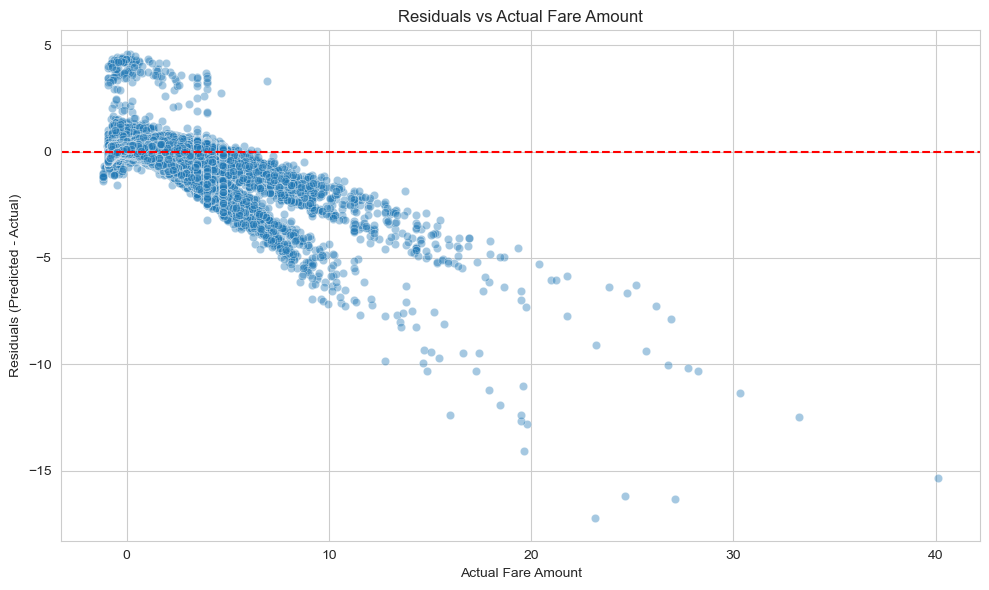

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate residuals
residuals = y_pred - y_valid

# Step 2: Plot residuals vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_valid, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual Fare Amount")
plt.xlabel("Actual Fare Amount")
plt.ylabel("Residuals (Predicted - Actual)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
import pandas as pd

# Example of new data (you can replace this with your actual new data)
new_data = pd.DataFrame({
    'fare_amount': [10.5, 20.7, 12.3],  # New fare amounts
    'passenger_count': [1, 2, 1],  # New passenger counts
    # Add other columns as needed
})


In [59]:
# Check the columns in new_data
print(new_data.columns)


Index(['fare_amount', 'passenger_count'], dtype='object')


In [63]:
# Re-importing necessary libraries and regenerating the synthetic data
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 500

# Generate synthetic data
pickup_datetime = pd.to_datetime(np.random.choice(pd.date_range("2023-01-01", "2023-12-31", freq="h"), size=n_samples))
passenger_count = np.random.randint(1, 5, size=n_samples)  # Random passenger count between 1 and 4
pickup_longitude = np.random.uniform(-74.3, -73.7, size=n_samples)  # Random longitude for NYC area
pickup_latitude = np.random.uniform(40.5, 40.9, size=n_samples)  # Random latitude for NYC area
dropoff_longitude = pickup_longitude + np.random.uniform(-0.05, 0.05, size=n_samples)  # Slight variation for dropoff
dropoff_latitude = pickup_latitude + np.random.uniform(-0.05, 0.05, size=n_samples)  # Slight variation for dropoff

# Calculate fare_amount based on some logic (just an approximation)
distance = np.sqrt((dropoff_longitude - pickup_longitude)**2 + (dropoff_latitude - pickup_latitude)**2)  # Rough distance
fare_amount = (distance * 10 + np.random.normal(20, 5, size=n_samples)) * passenger_count  # Base fare plus distance, adjusted by passenger count

# Creating the DataFrame
synthetic_data = pd.DataFrame({
    'pickup_datetime': pickup_datetime,
    'fare_amount': fare_amount,
    'passenger_count': passenger_count,
    'pickup_longitude': pickup_longitude,
    'pickup_latitude': pickup_latitude,
    'dropoff_longitude': dropoff_longitude,
    'dropoff_latitude': dropoff_latitude
})

# Show a snippet of the generated data
synthetic_data.head()

,pickup_datetime,fare_amount,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,2023-10-30 22:00:00,81.545489,3,-73.839332,40.896059,-73.841509,40.884010
1,2023-02-05 20:00:00,17.518782,1,-74.247626,40.770421,-74.247015,40.743094
2,2023-08-13 14:00:00,11.811585,1,-73.996338,40.678383,-74.023082,40.666545
3,2023-08-05 07:00:00,75.671381,4,-73.740791,40.759029,-73.782795,40.721914
4,2023-08-27 22:00:00,72.321233,4,-74.107615,40.737758,-74.079942,40.729034


In [67]:
# Step 1: Feature Engineering (Add month, day, and hour)
synthetic_data['pickup_month'] = synthetic_data['pickup_datetime'].dt.month
synthetic_data['pickup_day'] = synthetic_data['pickup_datetime'].dt.day
synthetic_data['pickup_hour'] = synthetic_data['pickup_datetime'].dt.hour

# Step 2: Check for missing values
print("Missing values in each column:")
print(synthetic_data.isnull().sum())

# Step 3: Convert all columns used for modeling to numeric
numeric_columns = ['fare_amount', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
                   'dropoff_longitude', 'dropoff_latitude', 'pickup_month', 'pickup_day', 'pickup_hour']

# Ensure all columns used in the model are of numeric type
synthetic_data[numeric_columns] = synthetic_data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Step 4: Drop the 'pickup_datetime' column as it is no longer needed
synthetic_data.drop(columns=['pickup_datetime'], inplace=True)

# Step 5: Train/Test Split
from sklearn.model_selection import train_test_split

# Define the features (X) and the target (y)
X = synthetic_data.drop(columns=['fare_amount'])
y = synthetic_data['fare_amount']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Model Training (Linear Regression)
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate RMSE and R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Output the results
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')


Missing values in each column:
pickup_datetime      0
fare_amount          0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
pickup_month         0
pickup_day           0
pickup_hour          0
dtype: int64
Root Mean Squared Error (RMSE): 14.130619321517472
R² Score: 0.694364024193145


## Evaluation

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicting on the test data
y_pred = model.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Compute R² Score
r2 = r2_score(y_test, y_pred)

rmse, r2

(14.130619321517472, 0.694364024193145)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Redefining the necessary data preparation and splitting
X = synthetic_data[['passenger_count', 'pickup_longitude', 'pickup_latitude', 
                    'dropoff_longitude', 'dropoff_latitude', 'pickup_month', 'pickup_day', 'pickup_hour']]
y = synthetic_data['fare_amount']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting on the test data
y_pred = model.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Compute R² Score
r2 = r2_score(y_test, y_pred)

rmse, r2


(14.130619321517472, 0.694364024193145)

## Improvements

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and test sets
X = synthetic_data.drop(['fare_amount'], axis=1)
  # Drop target variable and datetime
y = synthetic_data['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Set up a parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# RandomizedSearchCV to find the best parameters
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, 
                                   n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
random_search.fit(X_train, y_train)

# Best parameters found
best_rf_model = random_search.best_estimator_

# Evaluate the model
y_pred = best_rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True}
Root Mean Squared Error (RMSE): 14.63793558868166
R² Score: 0.6720242430099281


## Visualisations

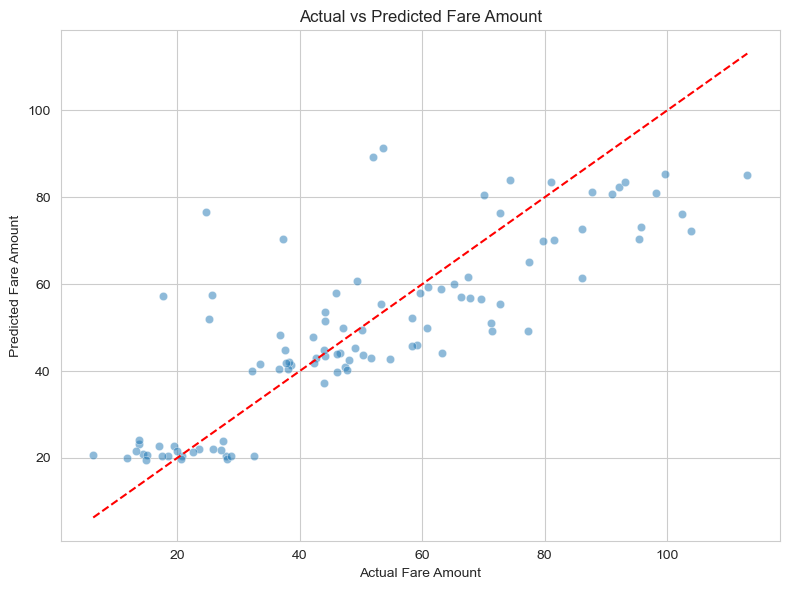

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Perfect prediction line
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted Fare Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

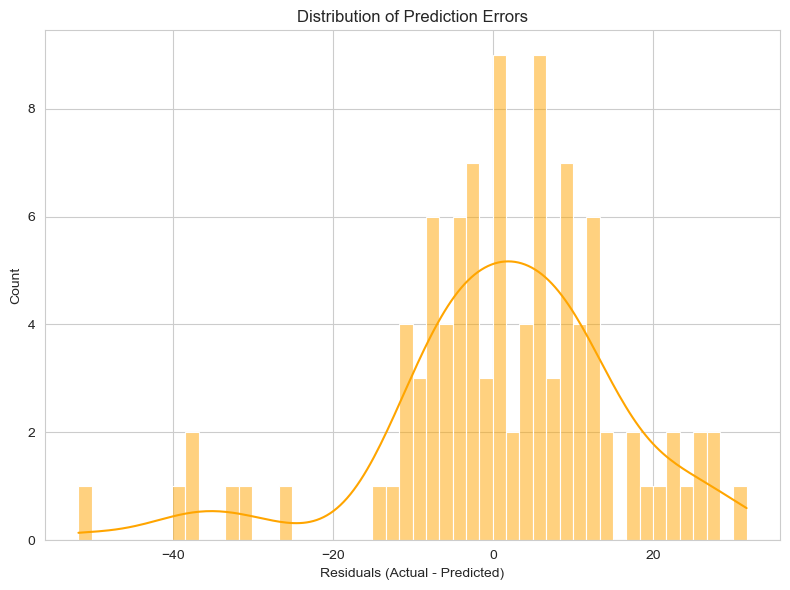

In [86]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True, color='orange')
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.tight_layout()
plt.show()